# Using PCA for an simulation of gene expression count

In [1]:
import pandas as pd
import numpy as np
import random as rd

from sklearn.decomposition import PCA
from sklearn import preprocessing
import matplotlib.pyplot as plt

In [2]:
genes = ['Gene' + str(i) for i in range(1, 101)]

In [3]:
wd = ['wd' + str(i) for i in range(1, 6)]
ko = ['ko' + str(i) for i in range(1, 6)]

In [4]:
data = pd.DataFrame(columns = [*wd, *ko], index = genes)

In [5]:
for gene in data.index:
    data.loc[gene, 'wd1':'wd5'] = np.random.poisson(lam = rd.randrange(10, 1000), size = 5)
    data.loc[gene, 'ko1':'ko5'] = np.random.poisson(lam = rd.randrange(10, 1000), size = 5)

In [6]:
data

,wd1,wd2,wd3,wd4,wd5,ko1,ko2,ko3,ko4,ko5
Gene1,808,814,802,846,829,412,409,430,364,396
Gene2,593,670,660,664,661,958,996,1008,939,975
Gene3,528,505,552,515,477,90,103,91,109,107
Gene4,575,616,630,610,581,462,441,476,474,495
Gene5,218,236,249,242,231,85,90,98,101,97
...,...,...,...,...,...,...,...,...,...,...
Gene96,947,936,961,918,945,751,733,741,779,809
Gene97,697,729,695,675,725,663,637,660,682,718
Gene98,542,569,600,528,542,483,456,463,486,463
Gene99,197,185,187,184,204,729,774,797,704,858


In [7]:
data.shape

(100, 10)

Standardise the data

In [8]:
scaled_data = preprocessing.StandardScaler().fit_transform(data.T)

In [9]:
scaled_data.shape

(10, 100)

Model PCA

In [10]:
pca = PCA()
pca.fit(scaled_data)
pca_data = pca.transform(scaled_data)

In [11]:
pca_data

array([[ 9.71752477e+00, -9.83359363e-01,  1.17709900e+00,
         5.08375741e-01, -1.22451506e+00, -5.29829338e-01,
        -1.68137306e-01,  8.78865411e-01, -7.70937678e-01,
         7.89068514e-16],
       [ 9.43394687e+00,  2.44588978e+00, -1.08341569e+00,
        -5.23161110e-01,  3.13323765e-01,  9.90739043e-01,
         8.10866072e-01,  9.16280958e-01,  1.49278081e-01,
        -5.43199115e-16],
       [ 9.82053841e+00, -3.10514861e-01,  1.58461664e-01,
        -3.60948374e-01,  1.37893229e+00, -1.87169986e+00,
         6.29319173e-01, -3.36065427e-01,  1.84672597e-01,
        -1.09831063e-15],
       [ 9.50670165e+00, -1.37441841e+00,  1.00490170e+00,
        -1.06272920e+00, -2.17617083e-01,  1.40842350e+00,
         3.66425026e-01, -1.13032324e+00, -3.68280204e-02,
         1.17764657e-15],
       [ 9.39060198e+00,  2.88871732e-01, -1.25508532e+00,
         1.44034253e+00, -2.38494835e-01,  4.66346170e-02,
        -1.67198316e+00, -3.36055564e-01,  4.71681928e-01,
         1.

Scree Plot

In [12]:
var = np.round(pca.explained_variance_ratio_*100, decimals = 2)
labels = ['PC' + str(i) for i in range(1, len(var) + 1)]

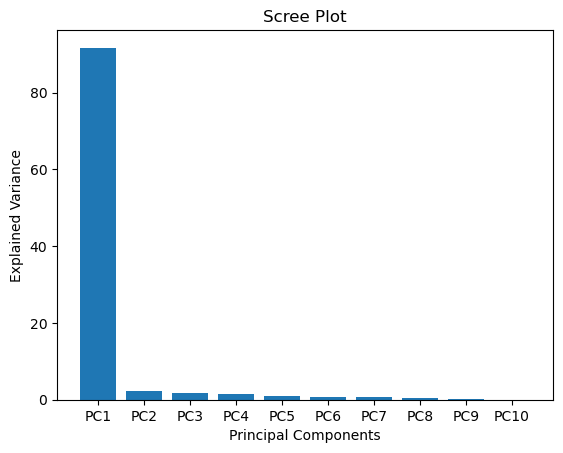

In [13]:
plt.bar(x = range(1, len(var) + 1), height = var, tick_label = labels)
plt.ylabel('Explained Variance')
plt.xlabel('Principal Components')
plt.title('Scree Plot')
plt.show()

Plot PCA with PC1 and PC2

In [14]:
pca_df = pd.DataFrame(pca_data, columns = labels, index = [*wd, *ko]) 

In [15]:
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
wd1,9.717525,-0.983359,1.177099,0.508376,-1.224515,-0.529829,-0.168137,0.878865,-0.770938,7.890685e-16
wd2,9.433947,2.445890,-1.083416,-0.523161,0.313324,0.990739,0.810866,0.916281,0.149278,-5.431991e-16
wd3,9.820538,-0.310515,0.158462,-0.360948,1.378932,-1.871700,0.629319,-0.336065,0.184673,-1.098311e-15
wd4,9.506702,-1.374418,1.004902,-1.062729,-0.217617,1.408423,0.366425,-1.130323,-0.036828,1.177647e-15
wd5,9.390602,0.288872,-1.255085,1.440343,-0.238495,0.046635,-1.671983,-0.336056,0.471682,1.191240e-17
ko1,-9.713743,-0.581254,-0.974940,-1.315539,1.348303,0.304590,-1.020389,0.200590,-0.692068,-2.656434e-16
ko2,-9.311567,-2.150325,-1.628414,-0.904345,-1.113283,-0.308202,0.480915,0.391296,0.599689,8.862130e-16
ko3,-9.533445,-0.481394,-0.406790,2.748842,0.521446,0.448154,0.974120,-0.258254,-0.271399,-1.042799e-15
ko4,-9.657967,0.394507,2.944784,0.057026,0.431780,0.223924,-0.444232,0.511535,0.637597,-1.819956e-15
ko5,-9.652591,2.751996,0.063399,-0.587863,-1.199875,-0.712734,0.043096,-0.837870,-0.271687,-5.987103e-16


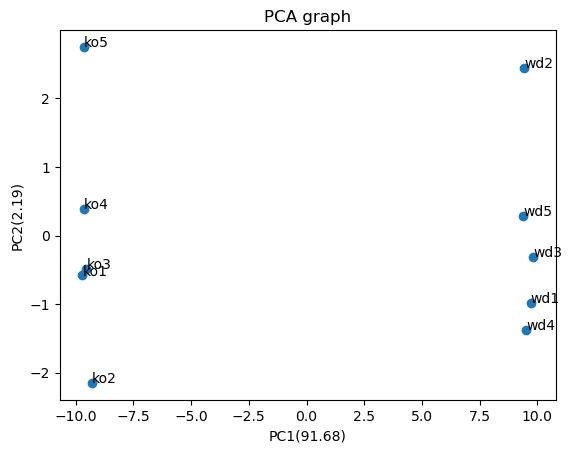

In [16]:
plt.scatter(pca_df.PC1, pca_df.PC2)
plt.title('PCA graph')
plt.xlabel(f'PC1({var[0]})')
plt.ylabel(f'PC2({var[1]})')

for sample in pca_df.index:
    plt.annotate(sample, (pca_df.PC1.loc[sample], pca_df.PC2.loc[sample]))

- The wt samples clustered on the left side suggest that they are correlated with each other and by extension the ko samples
- The seperation of the clusters of wd and ko samples suggest that they are very different from one another

Take a look at the loading scores for PC1 to determine which gene had the largest influence

In [17]:
loading_scores = pd.Series(pca.components_[0], index = genes)
sorted_loading_scores = loading_scores.abs().sort_values(ascending = False)

top_10_genes = sorted_loading_scores[0:10].index.values
print(loading_scores[top_10_genes])

Gene61    0.104336
Gene36    0.104334
Gene63    0.104311
Gene50    0.104296
Gene89    0.104294
Gene45   -0.104294
Gene59   -0.104291
Gene30   -0.104283
Gene95   -0.104273
Gene49    0.104271
dtype: float64


Given the scores are very similar, we can conclude that a large range of genes played a part in seperating the samples rather than being dominated by a select few genes